# ATS Baseline Workflow

This notebook shows how saved forecasting outputs can be plugged into a simple algorithmic trading system (ATS).

The workflow is:

1. load saved prediction timelines,
2. split the ATS stage into validation and test,
3. tune a simple trading parameter on ATS validation only,
4. freeze it,
5. evaluate the final portfolio on unseen ATS test.

This keeps forecasting and downstream trading evaluation cleanly separated.

In [1]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.append(str(SRC_ROOT))

from pipeline.prediction_timelines import (
    load_full_prediction_timeline,
    split_prediction_timeline_for_ats,
    prepare_bt_df_from_prediction_df,
)
from ats.strategy import PortfolioThresholdLongFlatStrategy
from ats.run_backtest import run_portfolio_backtest

print("Project root:", PROJECT_ROOT)

Project root: /home/advije/ml-ats-baseline


## Configuration

This notebook assumes that Notebook 1 has already been run and that prediction timelines have been saved to `outputs/predictions/`.

In [14]:
SELECTED_TICKERS = [
    "XOM",
    "AMZN",
    "AAPL",
    "JPM",
    "TSLA",
    "GOOGL",
    "WMT",
    "PG",
    "KO",
    "JNJ",
]

PREDICTIONS_DIR = PROJECT_ROOT / "outputs" / "predictions"
ATS_DIR = PROJECT_ROOT / "outputs" / "ats"

ATS_DIR.mkdir(parents=True, exist_ok=True)

THRESHOLD_GRID = [0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009]
INITIAL_CASH = 100000.0
COMMISSION = 0.001
ATS_VALIDATION_RATIO = 0.4

## Inspect one saved prediction timeline

We first inspect one ticker to verify that the saved prediction format is correct before running the full portfolio workflow.

In [3]:
example_ticker = "AMZN"
full_df = load_full_prediction_timeline(example_ticker, PREDICTIONS_DIR)

print(full_df.head())
print()
print(full_df.tail())
print()
print("Shape:", full_df.shape)
print("Columns:", full_df.columns.tolist())

        date    y_true     y_pred   prev_open  true_return  pred_return  \
0 2021-03-17  153.6610  155.97968  155.248505    -0.010226     0.004710   
1 2021-03-18  155.0500  156.54040  153.660995     0.009039     0.018739   
2 2021-03-19  151.4615  156.79880  155.050003    -0.023144     0.011279   
3 2021-03-22  153.3925  156.75842  151.461502     0.012749     0.034972   
4 2021-03-23  156.3500  156.86601  153.392502     0.019281     0.022645   

   true_direction  pred_direction  
0               0               1  
1               1               1  
2               0               1  
3               1               1  
4               1               1  

           date  y_true     y_pred   prev_open  true_return  pred_return  \
1211 2026-03-25  211.56  181.95694  207.949997     0.017360    -0.124997   
1212 2026-03-26  210.61  182.05540  211.559998    -0.004490    -0.139462   
1213 2026-03-27  206.46  182.09842  210.610001    -0.019705    -0.135376   
1214 2026-03-30  201.48  181

## Split ATS validation and ATS test

At the ATS stage, we perform another clean separation:

- ATS validation is used to choose the trading threshold,
- ATS test is used only once for final unseen evaluation.

In [4]:
amzn_ats_val_df, amzn_ats_test_df = split_prediction_timeline_for_ats(
    full_df,
    split_ratio=ATS_VALIDATION_RATIO,
)

print(
    "ATS validation:",
    amzn_ats_val_df.shape,
    "|",
    amzn_ats_val_df["date"].min(),
    "->",
    amzn_ats_val_df["date"].max(),
)

print(
    "ATS test:",
    amzn_ats_test_df.shape,
    "|",
    amzn_ats_test_df["date"].min(),
    "->",
    amzn_ats_test_df["date"].max(),
)

ATS validation: (486, 8) | 2021-03-17 00:00:00 -> 2023-05-02 00:00:00
ATS test: (730, 8) | 2023-05-03 00:00:00 -> 2026-03-31 00:00:00


In [5]:
amzn_val_bt = prepare_bt_df_from_prediction_df(amzn_ats_val_df)
amzn_test_bt = prepare_bt_df_from_prediction_df(amzn_ats_test_df)

print(amzn_val_bt.head())
print()
print(amzn_test_bt.head())
print()
print("Columns:", amzn_val_bt.columns.tolist())

                  open        high         low       close  volume  \
date                                                                 
2021-03-17  155.248505  155.248505  155.248505  155.248505     1.0   
2021-03-18  153.660995  153.660995  153.660995  153.660995     1.0   
2021-03-19  155.050003  155.050003  155.050003  155.050003     1.0   
2021-03-22  151.461502  151.461502  151.461502  151.461502     1.0   
2021-03-23  153.392502  153.392502  153.392502  153.392502     1.0   

            pred_return  
date                     
2021-03-17     0.004710  
2021-03-18     0.018739  
2021-03-19     0.011279  
2021-03-22     0.034972  
2021-03-23     0.022645  

                  open        high         low       close  volume  \
date                                                                 
2023-05-03  101.470001  101.470001  101.470001  101.470001     1.0   
2023-05-04  103.739998  103.739998  103.739998  103.739998     1.0   
2023-05-05  104.040001  104.040001  104.040001

## Trading strategy

We use a simple portfolio-level long/flat strategy.

At each trading step:

- if a stock's predicted return is above a threshold, it becomes active,
- all active stocks receive equal portfolio weight,
- non-active stocks remain flat.

This threshold is tuned on ATS validation only and then frozen for ATS test.

In [6]:
val_data_dict = {}
test_data_dict = {}

for ticker in SELECTED_TICKERS:
    full_df = load_full_prediction_timeline(ticker, PREDICTIONS_DIR)

    ats_val_df, ats_test_df = split_prediction_timeline_for_ats(
        full_df,
        split_ratio=ATS_VALIDATION_RATIO,
    )

    val_data_dict[ticker] = prepare_bt_df_from_prediction_df(ats_val_df)
    test_data_dict[ticker] = prepare_bt_df_from_prediction_df(ats_test_df)

print("Portfolio tickers:", list(val_data_dict.keys()))
print()
print(val_data_dict["AMZN"].head())

Portfolio tickers: ['XOM', 'AMZN', 'AAPL', 'JPM', 'TSLA', 'GOOGL', 'WMT', 'PG', 'KO', 'JNJ']

                  open        high         low       close  volume  \
date                                                                 
2021-03-17  155.248505  155.248505  155.248505  155.248505     1.0   
2021-03-18  153.660995  153.660995  153.660995  153.660995     1.0   
2021-03-19  155.050003  155.050003  155.050003  155.050003     1.0   
2021-03-22  151.461502  151.461502  151.461502  151.461502     1.0   
2021-03-23  153.392502  153.392502  153.392502  153.392502     1.0   

            pred_return  
date                     
2021-03-17     0.004710  
2021-03-18     0.018739  
2021-03-19     0.011279  
2021-03-22     0.034972  
2021-03-23     0.022645  


In [17]:
trial_out = run_portfolio_backtest(
    data_dict=val_data_dict,
    strategy_cls=PortfolioThresholdLongFlatStrategy,
    threshold=0.003,
    initial_cash=INITIAL_CASH,
    commission=COMMISSION,
)

pd.DataFrame([trial_out["summary"]])

,final_value,cumulative_return,sharpe,max_drawdown,trade_count,threshold
0,96302.171071,-0.036978,0.076809,-0.391531,1029,0.003


## Tune the trading threshold on ATS validation only

We now evaluate a small grid of threshold values on ATS validation data.

The best threshold is selected from validation only and then frozen before running the final ATS test.

In [18]:
def tune_portfolio_on_validation(
    val_data_dict,
    threshold_grid,
    initial_cash=100000.0,
    commission=0.001,
):
    rows = []

    for threshold in threshold_grid:
        out = run_portfolio_backtest(
            data_dict=val_data_dict,
            strategy_cls=PortfolioThresholdLongFlatStrategy,
            threshold=threshold,
            initial_cash=initial_cash,
            commission=commission,
        )

        row = out["summary"].copy()
        rows.append(row)

    tuning_df = pd.DataFrame(rows).sort_values(
        by=["sharpe", "cumulative_return", "trade_count"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    best_row = tuning_df.iloc[0].to_dict()
    return tuning_df, best_row

In [16]:
val_tuning_df, best_val_row = tune_portfolio_on_validation(
    val_data_dict=val_data_dict,
    threshold_grid=THRESHOLD_GRID,
    initial_cash=INITIAL_CASH,
    commission=COMMISSION,
)

val_tuning_df

,final_value,cumulative_return,sharpe,max_drawdown,trade_count,threshold
0,101971.843219,0.019718,0.173716,-0.348441,819,0.007
1,99855.401872,-0.001446,0.137794,-0.414154,1112,0.002
2,96302.171071,-0.036978,0.076809,-0.391531,1029,0.003
3,92315.971984,-0.076840,-0.002837,-0.318220,808,0.008
4,91883.348393,-0.081167,-0.008337,-0.329359,914,0.005
5,91890.346901,-0.081097,-0.012600,-0.377138,871,0.006
6,89479.563094,-0.105204,-0.060619,-0.300327,757,0.009
7,83596.604261,-0.164034,-0.187835,-0.421081,967,0.004


In [19]:
best_threshold = float(best_val_row["threshold"])
print("Selected threshold from ATS validation:", best_threshold)

Selected threshold from ATS validation: 0.007


In [20]:
val_tuning_df.to_csv(ATS_DIR / "validation_tuning.csv", index=False)

with open(ATS_DIR / "selected_ats_params.json", "w") as f:
    json.dump({"threshold": best_threshold}, f, indent=2)

print("Saved validation tuning results.")

Saved validation tuning results.


## Final unseen ATS test evaluation

Now we run the final portfolio evaluation on ATS test using the frozen threshold selected above.

No further tuning is performed here.

In [21]:
test_out = run_portfolio_backtest(
    data_dict=test_data_dict,
    strategy_cls=PortfolioThresholdLongFlatStrategy,
    threshold=best_threshold,
    initial_cash=INITIAL_CASH,
    commission=COMMISSION,
)

pd.DataFrame([test_out["summary"]])

,final_value,cumulative_return,sharpe,max_drawdown,trade_count,threshold
0,130524.72044,0.305247,0.445137,-0.328115,394,0.007


In [22]:
test_daily_returns = test_out["daily_returns"]
test_metrics_df = pd.DataFrame([test_out["summary"]])

if isinstance(test_daily_returns, pd.Series):
    test_daily_returns.rename("portfolio_return").to_csv(
        ATS_DIR / "test_daily_returns.csv",
        index=True,
    )
else:
    test_daily_returns.to_csv(ATS_DIR / "test_daily_returns.csv", index=True)

test_metrics_df.to_csv(ATS_DIR / "test_portfolio_metrics.csv", index=False)

print("Saved ATS test outputs.")
test_metrics_df

Saved ATS test outputs.


,final_value,cumulative_return,sharpe,max_drawdown,trade_count,threshold
0,130524.72044,0.305247,0.445137,-0.328115,394,0.007


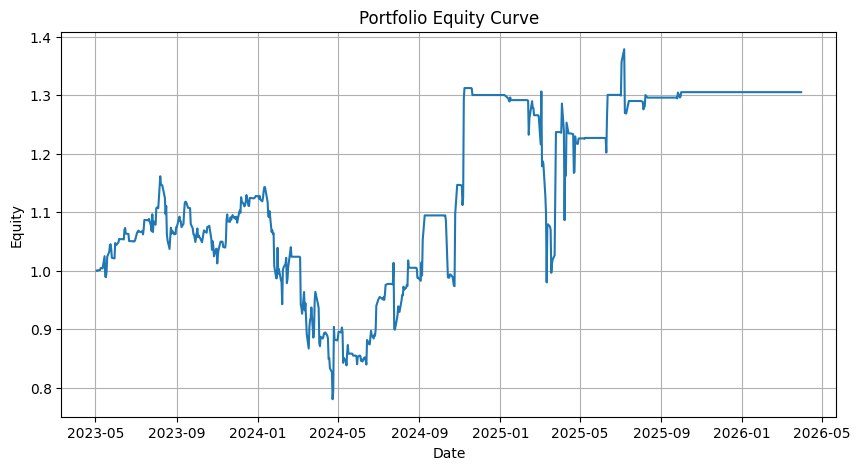

In [23]:
if isinstance(test_daily_returns, pd.DataFrame):
    portfolio_returns = test_daily_returns.iloc[:, 0].fillna(0.0)
else:
    portfolio_returns = test_daily_returns.fillna(0.0)

equity_curve = (1.0 + portfolio_returns).cumprod()

plt.figure(figsize=(10, 5))
plt.plot(equity_curve.index, equity_curve.values)
plt.title("Portfolio Equity Curve")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.grid(True)
plt.show()

## Key takeaway

This notebook separates:

- forecasting development in Notebook 1,
- ATS validation in this notebook,
- final ATS test evaluation in this notebook.

This is important because the trading parameter should be selected on ATS validation only and then frozen before final ATS evaluation.

The same structure can later be extended to more advanced studies, such as rolling retraining, alternative ATS rules, or robustness experiments.